# CE221 Nonlinear Structural Analysis

Instructor: Professor Khalid M. Mosalam<br>
Taisei Professor of Civil Engineering<br>
Director, Pacific Earthquake Engineering Research (PEER) Center<br>

Department of Civil and Environmental Engineering<br>
College of Engineering<br>
University of California, Berkeley<br>
Spring 2026

## CE221 Notebook 0 — Sanity Check

This Jupyter notebook was prepared by Dr. Fan Hu under the guidance of Professor Khalid M. Mosalam.

**Goal:** Verify that your environment can run `OpenSees` through `Xara` (Python) and produce results/plots.

By the end, you should see:
- A printed displacement value close to $P/k$
- A simple load-displacement plot

The notebook will continue to be refined and expanded as the course materials evolve.

### Environment basics

In [11]:
import sys, platform, os
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Working directory:", os.getcwd())
print("Files here (first 10):", os.listdir(".")[:10])

Python: 3.11.14
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Working directory: /home/facundo/repositories/SEMM-Facundo-Pfeffer/CE221_NonLinearStructuralAnalysis/ce211_hw1
Files here (first 10): ['CE221_HW2_Report_Dashboard.html', 'NB1_figure3.png', 'fig_p.html', 'newplot.png:Zone.Identifier', 'NB1_figure4.png', 'tip_displacement.html:Zone.Identifier', '04S.png:Zone.Identifier', 'tip_displacement.html', 'fig_np_coro.html', '04S.png']


### Import Xara

Official Documentations: [Xara](https://xara.so).

In [12]:
try:
    import xara
    print("Xara imported successfully.")
except Exception as e:
    # !pip install -U xara
    import xara
    print("Xara was not installed. Please install it manually.")

Xara imported successfully.


### Import Python libraries

We will be using some common Python libraries to help with data processing. By convention, all libraries are imported at the top of the notebook.
It is also standard practice to use short aliases for convenience (e.g., `np` for `numpy`). Run the cell below to import the libraries required.

In [13]:
import numpy as np
from numpy import sqrt
import matplotlib.pyplot as plt

### Build a linear 1D spring model

In [14]:
# Create a 1D model with 1 DOF per node
m = xara.Model(ndm=1, ndf=1)

# Nodes
m.node(1, 0.0)
m.node(2, 0.0)

# Fix node 1
m.fix(1, 1)

# Linear spring: Elastic material + zeroLength element
k = 1000.0
#                 (type, $matTag, stiffness E)
m.uniaxialMaterial("Elastic", 1, k)

#        ("zeroLength", $eleTag, $iNode, $jNode, "-mat", $matTag, "-dir", $dir)
m.element("zeroLength", 1, 1, 2, "-mat", 1, "-dir", 1)

print("Model built. Stiffness k =", k)

Model built. Stiffness k = 1000.0


### Apply load and run a one-step static analysis

In [15]:
# Define load
P = 10.0
m.pattern("Plain", 1, "Linear")
m.load(2, P, pattern=1)

# Analysis setup (robust, simple)
m.system("BandGeneral")
m.numberer("Plain")
m.constraints("Plain")
m.algorithm("Linear")
m.integrator("LoadControl", 1.0)
m.analysis("Static")

ok = m.analyze(1)
if ok != 0:
    raise RuntimeError("Analysis failed to converge in the sanity check (unexpected).")

u = m.nodeDisp(2, 1)
print(f"Analysis done. Node 2 displacement u = {u:.6g}")
print(f"Expected u = P/k = {P/k:.6g}")


Analysis done. Node 2 displacement u = 0.01
Expected u = P/k = 0.01


### Generate a load-displacement curve

In [16]:
# Rebuild cleanly for multi-step curve
m = xara.Model(ndm=1, ndf=1)
m.node(1, 0.0); m.node(2, 0.0)
m.fix(1, 1)
m.uniaxialMaterial("Elastic", 1, k)
m.element("zeroLength", 1, 1, 2, "-mat", 1, "-dir", 1)

m.pattern("Plain", 1, "Linear")
m.load(2, P, pattern=1)

m.system("BandGeneral")
m.numberer("Plain")
m.constraints("Plain")
m.algorithm("Linear")
m.analysis("Static")

n_steps = 10
m.integrator("LoadControl", 1.0 / n_steps)

U, F = [], []
for i in range(n_steps):
    ok = m.analyze(1)
    if ok != 0:
        raise RuntimeError(f"Analysis failed at step {i+1}/{n_steps}")

    U.append(m.nodeDisp(2, 1))

    # time tracks the load factor
    lf = m.getTime()
    F.append(lf * P)

U = np.array(U)
F = np.array(F)

print("Generated points:", len(U))
print("Last point:", "F =", F[-1], ", U =", U[-1])


Generated points: 10
Last point: F = 9.999999999999998 , U = 0.009999999999999998


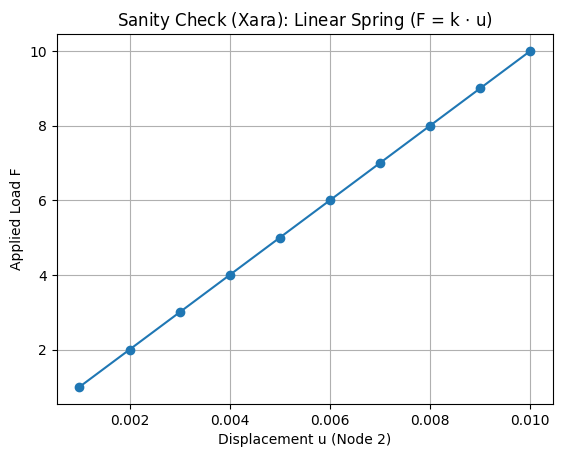

Estimated stiffness from curve: 1000.000 (target 1000.0)


In [17]:
plt.figure()
plt.plot(U, F, marker="o")
plt.xlabel("Displacement u (Node 2)")
plt.ylabel("Applied Load F")
plt.title("Sanity Check (Xara): Linear Spring (F = k $\cdot$ u)")
plt.grid(True)
plt.show()

k_est = (F[-1] - F[0]) / (U[-1] - U[0])
print(f"Estimated stiffness from curve: {k_est:.3f} (target {k})")

In [ ]:
import plotly.graph_objects as go

def run_spring_curve(k, P, n_steps):
    """Run load-controlled static analysis for 1D linear spring; return (U, F) arrays."""
    m = xara.Model(ndm=1, ndf=1)
    m.node(1, 0.0)
    m.node(2, 0.0)
    m.fix(1, 1)
    m.uniaxialMaterial("Elastic", 1, k)
    m.element("zeroLength", 1, 1, 2, "-mat", 1, "-dir", 1)
    m.pattern("Plain", 1, "Linear")
    m.load(2, P, pattern=1)
    m.system("BandGeneral")
    m.numberer("Plain")
    m.constraints("Plain")
    m.algorithm("Linear")
    m.analysis("Static")
    m.integrator("LoadControl", 1.0 / n_steps)
    U, F = [], []
    for _ in range(n_steps):
        ok = m.analyze(1)
        if ok != 0:
            raise RuntimeError("Analysis failed to converge")
        U.append(m.nodeDisp(2, 1))
        F.append(m.getTime() * P)
    return np.array(U), np.array(F)

# Plot style (match previous Plotly plots)
FONT_FAMILY = "Arial"
FONT_TITLE, FONT_AXIS, FONT_TICK = 20, 15, 15
FIG_W, FIG_H = 800, 500

# --- Comparison: different stiffness k (fixed P, n_steps) ---
P_ref = 10.0
n_steps_ref = 7
k_values = [500.0, 1000.0, 2000.0]
colors_k = ["#1e3a8a", "#166534", "#991b1b"]

fig_k = go.Figure()
for k, color in zip(k_values, colors_k):
    U, F = run_spring_curve(k, P_ref, n_steps_ref)
    U = np.concatenate([[0.0], U]); F = np.concatenate([[0.0], F])
    fig_k.add_trace(go.Scatter(
        x=U, y=F, mode="lines+markers", name=f"k = {k}",
        line=dict(color=color, width=2), marker=dict(size=8, color=color),
        hovertemplate="u = %{x:.4f}<br>F = %{y:.4f}<extra></extra>",
    ))
fig_k.update_layout(
    title=dict(text="Linear Spring (F = k · u): comparison for different stiffness k", font=dict(size=FONT_TITLE, color="#1e293b", family=FONT_FAMILY), x=0.5, xanchor="center", y=0.99, yanchor="top"),
    xaxis=dict(title=dict(text="Displacement u (Node 2)", font=dict(size=FONT_AXIS, color="#475569", family=FONT_FAMILY)), tickfont=dict(size=FONT_TICK, color="#64748b", family=FONT_FAMILY), showgrid=True, gridcolor="rgba(148,163,184,0.25)", zeroline=True, showline=True, linecolor="#cbd5e1", linewidth=1.2, mirror=True),
    yaxis=dict(title=dict(text="Applied Load F", font=dict(size=FONT_AXIS, color="#475569", family=FONT_FAMILY)), tickfont=dict(size=FONT_TICK, color="#64748b", family=FONT_FAMILY), showgrid=True, gridcolor="rgba(148,163,184,0.25)", zeroline=True, showline=True, linecolor="#cbd5e1", linewidth=1.2, mirror=True),
    legend=dict(orientation="h", y=1.06, x=0.5, xanchor="center", yanchor="bottom", bgcolor="rgba(255,255,255,0)", bordercolor="rgba(255,255,255,0)", font=dict(size=FONT_TICK, color="#334155", family=FONT_FAMILY), itemsizing="constant", itemwidth=30),
    plot_bgcolor="#f8fafc", paper_bgcolor="white", margin=dict(t=100, b=60, l=78, r=48), width=FIG_W, height=FIG_H,
    font=dict(family=FONT_FAMILY, size=FONT_TICK, color="#334155"), hoverlabel=dict(bgcolor="white", font_size=14, font_family=FONT_FAMILY),
)
fig_k.show(config=dict(displayModeBar=False))
fig_k.write_html(
    "fig_k.html",
    include_plotlyjs="cdn",   # small file; requires internet to view
    full_html=True
)
# --- Comparison: different load increments n_steps (fixed k, P) ---
k_ref = 1000.0
n_steps_list = [5, 7, 11]
colors_n = ["#1e3a8a", "#166534", "#991b1b"]

fig_steps = go.Figure()
for n_steps, color in zip(n_steps_list, colors_n):
    U, F = run_spring_curve(k_ref, P_ref, n_steps)
    U = np.concatenate([[0.0], U]); F = np.concatenate([[0.0], F])
    fig_steps.add_trace(go.Scatter(
        x=U, y=F, mode="lines+markers", name=f"n_steps = {n_steps}",
        line=dict(color=color, width=2), marker=dict(size=8, color=color),
        hovertemplate="u = %{x:.4f}<br>F = %{y:.4f}<extra></extra>",
    ))
fig_steps.update_layout(
    title=dict(text="Linear Spring (F = k · u): comparison for different load increments", font=dict(size=FONT_TITLE, color="#1e293b", family=FONT_FAMILY), x=0.5, xanchor="center", y=0.99, yanchor="top"),
    xaxis=dict(title=dict(text="Displacement u (Node 2)", font=dict(size=FONT_AXIS, color="#475569", family=FONT_FAMILY)), tickfont=dict(size=FONT_TICK, color="#64748b", family=FONT_FAMILY), showgrid=True, gridcolor="rgba(148,163,184,0.25)", zeroline=True, showline=True, linecolor="#cbd5e1", linewidth=1.2, mirror=True),
    yaxis=dict(title=dict(text="Applied Load F", font=dict(size=FONT_AXIS, color="#475569", family=FONT_FAMILY)), tickfont=dict(size=FONT_TICK, color="#64748b", family=FONT_FAMILY), showgrid=True, gridcolor="rgba(148,163,184,0.25)", zeroline=True, showline=True, linecolor="#cbd5e1", linewidth=1.2, mirror=True),
    legend=dict(orientation="h", y=1.06, x=0.5, xanchor="center", yanchor="bottom", bgcolor="rgba(255,255,255,0)", bordercolor="rgba(255,255,255,0)", font=dict(size=FONT_TICK, color="#334155", family=FONT_FAMILY), itemsizing="constant", itemwidth=30),
    plot_bgcolor="#f8fafc", paper_bgcolor="white", margin=dict(t=100, b=60, l=78, r=48), width=FIG_W, height=FIG_H,
    font=dict(family=FONT_FAMILY, size=FONT_TICK, color="#334155"), hoverlabel=dict(bgcolor="white", font_size=14, font_family=FONT_FAMILY),
)
fig_steps.show(config=dict(displayModeBar=False))

fig_steps.write_html(
    "fig_steps.html",
    include_plotlyjs="cdn",   # small file; requires internet to view
    full_html=True
)

# --- Load–Unload cycle (second loading branch): Plotly ---
k = 1000
P = 10.0
m = xara.Model(ndm=1, ndf=1)
m.node(1, 0.0)
m.node(2, 0.0)
m.fix(1, 1)
m.uniaxialMaterial("Elastic", 1, k)
m.element("zeroLength", 1, 1, 2, "-mat", 1, "-dir", 1)
m.pattern("Plain", 1, "Linear")
m.load(2, P, pattern=1)
m.system("BandGeneral")
m.numberer("Plain")
m.constraints("Plain")
m.algorithm("Linear")
m.analysis("Static")

# Phase 1: Loading up
n_steps_load = 20
dLambda_load = 1.0 / n_steps_load
m.integrator("LoadControl", dLambda_load)
U_load, F_load = [0.0], [0.0]
for i in range(n_steps_load):
    ok = m.analyze(1)
    if ok != 0:
        raise RuntimeError(f"Loading failed at step {i+1}")
    U_load.append(m.nodeDisp(2, 1))
    F_load.append(m.getTime() * P)

# Phase 2: Unloading to P/2
P_min = P / 2
n_steps_unload = 5
current_lf = m.getTime()
target_lf = P_min / P
dLambda_unload = (target_lf - current_lf) / n_steps_unload
m.integrator("LoadControl", dLambda_unload)
U_unload, F_unload = [U_load[-1]], [F_load[-1]]
for i in range(n_steps_unload):
    ok = m.analyze(1)
    if ok != 0:
        raise RuntimeError(f"Unloading failed at step {i+1}")
    U_unload.append(m.nodeDisp(2, 1))
    F_unload.append(m.getTime() * P)

U_load = np.array(U_load)
F_load = np.array(F_load)
U_unload = np.array(U_unload)
F_unload = np.array(F_unload)

fig_load_unload = go.Figure()
fig_load_unload.add_trace(go.ScatWter(
    x=U_load, y=F_load, mode="lines+markers", name="Loading",
    line=dict(color="#1e3a8a", width=2),
    marker=dict(size=8, color="#1e3a8a"),
    hovertemplate="u = %{x:.4f}<br>F = %{y:.4f}<extra></extra>",
))
fig_load_unload.add_trace(go.Scatter(
    x=U_unload, y=F_unload, mode="lines+markers", name="Unloading",
    line=dict(color="#ea580c", width=2, dash="dash"),
    marker=dict(size=8, color="#ea580c"),
    hovertemplate="u = %{x:.4f}<br>F = %{y:.4f}<extra></extra>",
))
fig_load_unload.update_layout(
    title=dict(text=f"Load–Unload Cycle (k = {k})", font=dict(size=FONT_TITLE, color="#1e293b", family=FONT_FAMILY), x=0.5, xanchor="center", y=0.99, yanchor="top"),
    xaxis=dict(title=dict(text="Displacement u (Node 2)", font=dict(size=FONT_AXIS, color="#475569", family=FONT_FAMILY)), tickfont=dict(size=FONT_TICK, color="#64748b", family=FONT_FAMILY), showgrid=True, gridcolor="rgba(148,163,184,0.25)", zeroline=True, showline=True, linecolor="#cbd5e1", linewidth=1.2, mirror=True),
    yaxis=dict(title=dict(text="Force (P)", font=dict(size=FONT_AXIS, color="#475569", family=FONT_FAMILY)), tickfont=dict(size=FONT_TICK, color="#64748b", family=FONT_FAMILY), showgrid=True, gridcolor="rgba(148,163,184,0.25)", zeroline=True, showline=True, linecolor="#cbd5e1", linewidth=1.2, mirror=True),
    legend=dict(orientation="h", y=1.06, x=0.5, xanchor="center", yanchor="bottom", bgcolor="rgba(255,255,255,0)", bordercolor="rgba(255,255,255,0)", font=dict(size=FONT_TICK, color="#334155", family=FONT_FAMILY), itemsizing="constant", itemwidth=30),
    plot_bgcolor="#f8fafc", paper_bgcolor="white", margin=dict(t=100, b=60, l=78, r=48), width=FIG_W, height=FIG_H,
    font=dict(family=FONT_FAMILY, size=FONT_TICK, color="#334155"), hoverlabel=dict(bgcolor="white", font_size=14, font_family=FONT_FAMILY),
)
fig_load_unload.show(config=dict(displayModeBar=False))
fig_load_unload.write_html("fig_load_unload.html", include_plotlyjs="cdn", full_html=True)